In [2]:
import numpy as np
from quspin.basis import boson_basis_general
from quspin.operators import hamiltonian


# 1] 2D lattice of spin-s

In [356]:
Lx, Ly = 4, 2  # linear dimension of spin 1/2 2d lattice
U, mu = 32, 1

N_2d = Lx * Ly  # number of sites for spin 1/2
s = np.arange(N_2d)  # sites [0,1,2,....]
x = s % Lx  # x positions for sites
y = s // Lx  # y positions for sites
T_x = (x + 1) % Lx + Lx * y  # translation along x-direction
T_y = x + Lx * ((y + 1) % Ly)  # translation along y-direction
P_x = x + Lx * (Ly - y - 1)  # reflection about x-axis
P_y = (Lx - x - 1) + Lx * y  # reflection about y-axis
TT_x = (x + 2) % Lx + Lx * y  # translation along x-direction
TT_y = x + Lx * ((y + 2) % Ly)  # translation along y-direction
# Z = -(s + 1)  # spin inversion
# print(T_x.reshape(Lx, Ly))
# print(T_y.reshape(Lx, Ly))
# print(P_x.reshape(Lx, Ly))
# print(P_y.reshape(Lx, Ly))

In [357]:
###### setting up bases ######
sps=4
basis_2d = boson_basis_general(
    N_2d,
    sps=sps,
    # kxblock=(TT_x, 1),
    # kyblock=(TT_y, 1),
    # pxblock=(P_x, 1),
    # pyblock=(P_y, 1),
    # Nb=Nb
)
print("Size of 2D H-space: {Ns:d}".format(Ns=basis_2d.Ns))

Size of 2D H-space: 65536


In [358]:
print([state for state in basis_2d.states])
state = basis_2d.int_to_state(basis_2d.Ns-basis_2d.states[0]-1, bracket_notation=False)
# v0 = np.ze
print(state)

[np.uint32(65535), np.uint32(65534), np.uint32(65533), np.uint32(65532), np.uint32(65531), np.uint32(65530), np.uint32(65529), np.uint32(65528), np.uint32(65527), np.uint32(65526), np.uint32(65525), np.uint32(65524), np.uint32(65523), np.uint32(65522), np.uint32(65521), np.uint32(65520), np.uint32(65519), np.uint32(65518), np.uint32(65517), np.uint32(65516), np.uint32(65515), np.uint32(65514), np.uint32(65513), np.uint32(65512), np.uint32(65511), np.uint32(65510), np.uint32(65509), np.uint32(65508), np.uint32(65507), np.uint32(65506), np.uint32(65505), np.uint32(65504), np.uint32(65503), np.uint32(65502), np.uint32(65501), np.uint32(65500), np.uint32(65499), np.uint32(65498), np.uint32(65497), np.uint32(65496), np.uint32(65495), np.uint32(65494), np.uint32(65493), np.uint32(65492), np.uint32(65491), np.uint32(65490), np.uint32(65489), np.uint32(65488), np.uint32(65487), np.uint32(65486), np.uint32(65485), np.uint32(65484), np.uint32(65483), np.uint32(65482), np.uint32(65481), np.uint32

In [359]:
# setting up hamiltonians

def Htot_func(mu, U):
    # 2d (nx)
    hn_2d = [[mu, i] for i in range(N_2d)]
    Hn_2d = hamiltonian([["n", hn_2d]], [], basis=basis_2d, dtype=np.float64)

    # 2d (nx ny)
    Jnn_2d = [[U, i, T_x[i]] for i in range(N_2d)] + [[U, i, T_y[i]] for i in range(N_2d)]
    Hnn_2d = hamiltonian([["nn", Jnn_2d]], [], basis=basis_2d, dtype=np.float64)

    Htot = Hn_2d + Hnn_2d
    return Htot

Htot = Htot_func(mu, U)

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!


In [360]:
n_list = [
    hamiltonian([[
        "n", [[1.0, i]]
    ]], [], basis=basis_2d, check_symm=False)
    for i in range(N_2d)
]
print(n_list[0].shape)

ndiag_list = [n.diagonal() for n in n_list]

Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
(65536, 65536)


# 2] Compute expectation values of occupation number

In [372]:
from quspin.operators import exp_op
import scipy
# construct gibbs state

dtype_real = np.float64
list_T_over_mu = np.logspace(-1, 2, num=9)
all_avg_particle_number = []

for T_over_mu in list_T_over_mu:
    exp_Htot_diag = np.exp(- Htot.diagonal()/(T_over_mu * mu))
    traceless_exp_Htot_diag = exp_Htot_diag / exp_Htot_diag.sum()
    argsort = np.argsort(traceless_exp_Htot_diag)[::-1][0:500]
    avg_particle_number = np.zeros(N_2d)
    for index in argsort:
        state = basis_2d.int_to_state(basis_2d[index], bracket_notation=False)
        state_array = np.array(list(map(int, state))) * traceless_exp_Htot_diag[index]
        # print(state, traceless_exp_Htot_diag[index])
        if state_array[1]==0:
            avg_particle_number += state_array

    all_avg_particle_number.append(np.real(avg_particle_number))

print(np.round(all_avg_particle_number, decimals=1))

[[0.  0.  0.  0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0. ]
 [0.1 0.  0.1 0.1 0.1 0.1 0.1 0.1]
 [0.4 0.  0.4 0.2 0.2 0.4 0.2 0.3]
 [0.5 0.  0.5 0.2 0.2 0.5 0.2 0.5]
 [0.6 0.  0.6 0.2 0.2 0.6 0.2 0.5]
 [0.6 0.  0.6 0.2 0.2 0.6 0.2 0.6]
 [0.5 0.  0.5 0.2 0.2 0.5 0.2 0.5]
 [0.3 0.  0.3 0.1 0.1 0.3 0.1 0.2]]


In [366]:
# v0 = np.zeros(basis_2d.Ns)
# state = "000000011"
# v0[basis_2d.Ns - basis_2d.state_to_int(state)-1] = 1
# print(basis_2d.state_to_int(state))
# Htot.expt_value(v0)

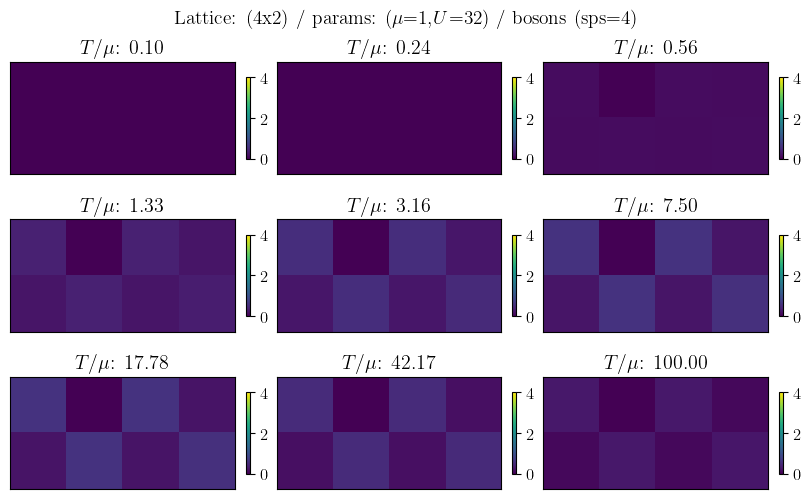

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif"
})
# print(all_avg_particle_number)

ncols = 3
fig, ax = plt.subplots(ncols = ncols, nrows=len(list_T_over_mu)//ncols, figsize = (8, 5), constrained_layout='tight')
for ii, T_over_mu, avg_particle_number in zip(range(len(list_T_over_mu)), list_T_over_mu, all_avg_particle_number):
    img = ax[ii//ncols][ii%ncols].imshow(np.round(avg_particle_number, decimals=2).reshape((Ly, Lx)), vmin=0, vmax = 4)
    ax[ii//ncols][ii%ncols].set_title(rf"$T/\mu$: {T_over_mu:.02f}")
    ax[ii//ncols][ii%ncols].set_xticks([])
    ax[ii//ncols][ii%ncols].set_yticks([])
    fig.colorbar(img, ax=ax[ii//ncols][ii%ncols], shrink=0.6)

plt.suptitle(f"Lattice: ({Lx}x{Ly}) / params: ($\mu$={mu},$U$={U}) / bosons (sps={sps})", fontsize=14)
plt.savefig(f"figures/lattice{Lx}x{Ly}_bosons_U{U}_sps{sps}.pdf")

# Plot top configurations at high-T

In [345]:
from quspin.operators import exp_op
import scipy
# construct gibbs state

dtype_real = np.float64
T_over_mu = 10
Htot = Htot_func(mu, 1000)

exp_Htot_diag = np.exp(- Htot.diagonal()/(T_over_mu * mu))
traceless_exp_Htot_diag = exp_Htot_diag / exp_Htot_diag.sum()

argsort = np.argsort(traceless_exp_Htot_diag)[::-1][:400]
tot_occupation_number = np.zeros(N_2d)
for index in argsort:
    state = basis_2d.int_to_state(basis_2d[index], bracket_notation=False)
    state_array = np.array(list(map(int, state))) * traceless_exp_Htot_diag[index]
    # print(state, traceless_exp_Htot_diag[index])
    if state_array[1]==0:
        tot_occupation_number += state_array


Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!


[0.45760721 0.         0.45601246 0.19951974 0.19792499 0.45920196
 0.19792499 0.4151137 ]


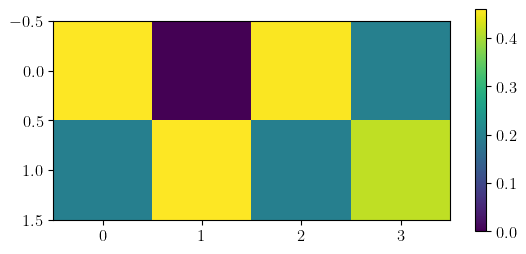

In [346]:
print(tot_occupation_number)
im = plt.imshow(tot_occupation_number.reshape(Ly, Lx))
plt.colorbar(im, shrink=0.6)